# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 26 - 4to bimestre 2026

## **Alumno 1:** Lerner, Federico Ezequiel - a2619

## **Alumno 2:** Makk, Azul de los Angeles - a2622

## **Alumno 3:** Moguilner Reh, Nicolás Francisco - a2623

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del domingo 4 de octubre (hora de Argentina)**.

La resolución del TP puede realizarse de forma **individual, en parejas o hasta en grupos de 3 como máximo**. Sin embargo, no se recomienda repartir las preguntas entre los integrantes, sino que todos los integrantes deben trabajar conjuntamente en la resolución de cada pregunta. De esta manera, se promueve el debate, la discusión y la construcción de una conclusión compartida sobre cómo abordar y resolver cada pregunta.

Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local. Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo en formato `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/PGDTphbnqZpcVK167)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERAPELLIDOALUMNO3-TP2-Co26.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP2-Co26.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option("display.width", 200)

# Si los CSV no están en la carpeta del notebook (por ejemplo en Colab), se bajan del Drive del curso
ARCHIVOS = {"adult_train.csv": "14NaASnZwTM2amJnMxz5E_6rczadZF4Zq",
            "adult_val.csv": "1tS0FPVDQ7cy1COgRZfS03oeOEHbOvSkN"}
for nombre, file_id in ARCHIVOS.items():
    if not os.path.exists(nombre):
        import gdown
        gdown.download(f"https://drive.google.com/uc?id={file_id}", nombre, quiet=True)

train_df = pd.read_csv("adult_train.csv")
val_df = pd.read_csv("adult_val.csv")
print("train:", train_df.shape, "| validation:", val_df.shape, "| device:", device)
train_df.head()

train: (30162, 14) | validation: (15060, 14) | device: cpu


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K


## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

age               int64
workclass           str
education           str
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
skill-profile       str
native-country      str
income              str
dtype: object 

Nulos en train: 0 | en validation: 0
Valores '?' en train: 0 | en validation: 0
Filas duplicadas en train: 479 | en validation: 118
Filas de validation idénticas a alguna de train: 405


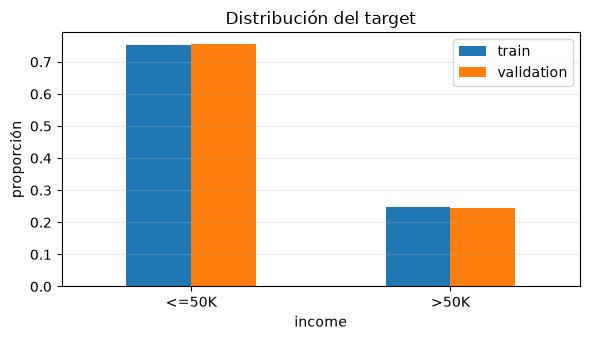

% con >50K: train 24.9% | validation 24.6%


In [2]:
print(train_df.dtypes, "\n")
print("Nulos en train:", int(train_df.isnull().sum().sum()), "| en validation:", int(val_df.isnull().sum().sum()))
def contar_signos(df):
    return int(sum((df[c].astype(str).str.strip() == "?").sum() for c in df.columns))
print("Valores '?' en train:", contar_signos(train_df), "| en validation:", contar_signos(val_df))
print("Filas duplicadas en train:", int(train_df.duplicated().sum()), "| en validation:", int(val_df.duplicated().sum()))
filas_train = set(map(tuple, train_df.values.tolist()))
print("Filas de validation idénticas a alguna de train:", sum(tuple(f) in filas_train for f in val_df.values.tolist()))

fig, ax = plt.subplots(figsize=(6, 3.5))
pd.DataFrame({"train": train_df["income"].value_counts(normalize=True),
              "validation": val_df["income"].value_counts(normalize=True)}).plot.bar(ax=ax, rot=0)
ax.set_title("Distribución del target"); ax.set_ylabel("proporción"); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()
print(f"% con >50K: train {(train_df['income'] == '>50K').mean():.1%} | validation {(val_df['income'] == '>50K').mean():.1%}")

Los datos vienen bastante limpios: no hay nulos ni valores `?` (que en la versión original del Adult suelen aparecer en workclass, occupation y native-country), y todas las categorías que aparecen en validation también están en train, así que no vamos a tener categorías nuevas al evaluar. Hay 479 filas repetidas en train y 118 en validation, y 405 filas de validation (2,7%) son idénticas a alguna de train. Las dejamos como están: sin un identificador no hay forma de saber si son la misma persona o dos personas distintas con las mismas características, y con 14 columnas, varias de ellas con pocos valores, que dos personas coincidan es bastante esperable. Tampoco nos pareció correcto tocar el split que da el TP. Sí lo tenemos en cuenta como limitación: si parte de esas filas fueran la misma persona, las métricas de validation serían algo optimistas.

El target está desbalanceado: alrededor del 75% gana <=50K y el 25% >50K, con casi la misma proporción en train (24,9%) y en validation (24,6%). Esto importa para las métricas, porque un modelo que responda siempre <=50K ya saca 75% de accuracy sin aprender nada. Por eso le damos más peso al F1 macro, que promedia el F1 de las dos clases y castiga si la clase minoritaria se predice mal.

### Variables numéricas

                  count    mean     std   min   25%   50%   75%      max
age             30162.0    38.4    13.1  17.0  28.0  37.0  47.0     90.0
hours-per-week  30162.0    40.9    12.0   1.0  40.0  40.0  45.0     99.0
capital-gain    30162.0  1092.0  7406.3   0.0   0.0   0.0   0.0  99999.0
capital-loss    30162.0    88.4   404.3   0.0   0.0   0.0   0.0   4356.0
age             ceros:   0.0% | asimetría:  0.53
hours-per-week  ceros:   0.0% | asimetría:  0.33
capital-gain    ceros:  91.6% | asimetría: 11.90
capital-loss    ceros:  95.3% | asimetría:  4.53
capital-gain = 99999 en 148 filas, de las cuales 100% son >50K
99999 estandarizado sin log: 13.4 desvíos
% con >50K si capital-gain > 0: 63% | si es 0: 21%
% con >50K si capital-loss > 0: 52% | si es 0: 24%
% con >50K con más de 40 horas: 41% | resto: 18%


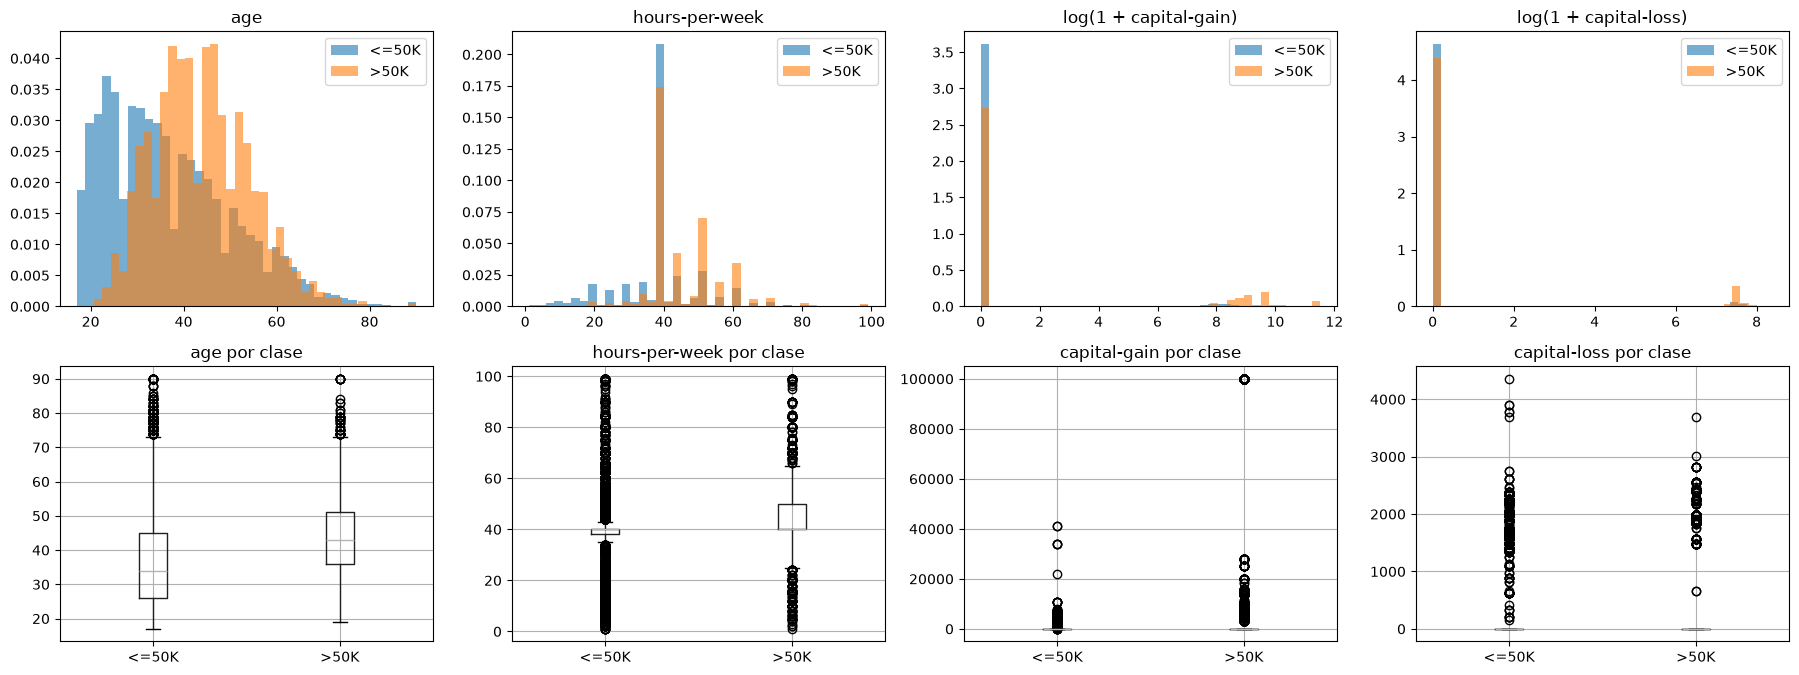

In [3]:
NUMERICAS = ["age", "hours-per-week", "capital-gain", "capital-loss"]
train_df["y"] = (train_df["income"] == ">50K").astype(int)

print(train_df[NUMERICAS].describe().round(1).T)
for c in NUMERICAS:
    print(f"{c:15s} ceros: {(train_df[c] == 0).mean():6.1%} | asimetría: {train_df[c].skew():5.2f}")
tope = train_df["capital-gain"] == 99999
print(f"capital-gain = 99999 en {int(tope.sum())} filas, de las cuales {train_df.loc[tope, 'y'].mean():.0%} son >50K")
print(f"99999 estandarizado sin log: {(99999 - train_df['capital-gain'].mean()) / train_df['capital-gain'].std():.1f} desvíos")
for c in ["capital-gain", "capital-loss"]:
    print(f"% con >50K si {c} > 0: {train_df.loc[train_df[c] > 0, 'y'].mean():.0%} | si es 0: {train_df.loc[train_df[c] == 0, 'y'].mean():.0%}")
mas_de_40 = train_df["hours-per-week"] > 40
print(f"% con >50K con más de 40 horas: {train_df.loc[mas_de_40, 'y'].mean():.0%} | resto: {train_df.loc[~mas_de_40, 'y'].mean():.0%}")

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for j, c in enumerate(NUMERICAS):
    datos = train_df[c] if c not in ("capital-gain", "capital-loss") else np.log1p(train_df[c])
    for clase, color in [(0, "tab:blue"), (1, "tab:orange")]:
        axes[0, j].hist(datos[train_df["y"] == clase], bins=40, alpha=0.6, color=color,
                        label="<=50K" if clase == 0 else ">50K", density=True)
    axes[0, j].set_title(c if c not in ("capital-gain", "capital-loss") else f"log(1 + {c})")
    axes[0, j].legend()
    train_df.boxplot(column=c, by="income", ax=axes[1, j])
    axes[1, j].set_title(f"{c} por clase"); axes[1, j].set_xlabel("")
plt.suptitle(""); plt.tight_layout(); plt.show()

Lo que sacamos de las numéricas:

- age: la clase >50K se concentra entre los 35 y los 55 años, mientras que <=50K tiene mucha más gente joven. Tiene sentido, porque el ingreso crece con la experiencia. La distribución es razonable (asimetría 0,53), así que alcanza con estandarizarla.
- hours-per-week: hay un pico enorme en 40 horas (jornada completa). Los que trabajan más de 40 horas tienen una tasa de >50K del 41%, contra 18% del resto. También la estandarizamos, sin otra transformación.
- capital-gain y capital-loss: son casi siempre cero (91,6% y 95,3% de las filas) y cuando no lo son toman valores muy grandes, con asimetrías de 11,9 y 4,5. Además hay 148 filas con capital-gain = 99999, que parece un tope de la encuesta más que un valor real; todas esas filas son >50K. Son variables muy informativas: con capital-gain > 0 el 63% gana >50K, contra 21% cuando es 0, y con capital-loss > 0 el 52%, contra 24%. Por eso no las descartamos ni recortamos los outliers. Les aplicamos `log1p` (log(1+x), que deja el 0 en 0) para comprimir la cola y después las estandarizamos. Sin el log, un 99999 estandarizado queda en más de 13 desvíos y domina la entrada de la red.

Todas las estandarizaciones usan media y desvío calculados solo con train, para no filtrar información de validation.

### Variables categóricas y cardinalidad

In [4]:
CATEGORICAS = ["workclass", "education", "marital-status", "occupation", "relationship",
               "race", "sex", "skill-profile", "native-country"]

filas = []
for c in CATEGORICAS:
    frec = train_df[c].value_counts(normalize=True)
    filas.append({"variable": c, "valores únicos": train_df[c].nunique(),
                  "cardinalidad": "alta (>= 10)" if train_df[c].nunique() >= 10 else "baja",
                  "valor más frecuente": frec.index[0], "% del más frecuente": round(100 * frec.iloc[0], 1),
                  "valores con < 1% de las filas": int((frec < 0.01).sum()),
                  "en validation y no en train": len(set(val_df[c]) - set(train_df[c]))})
tabla_cardinalidad = pd.DataFrame(filas).sort_values("valores únicos")
display(tabla_cardinalidad)

# Valores de cada variable (native-country se ve completa en el gráfico de más abajo y skill-profile se analiza aparte)
for c in tabla_cardinalidad["variable"]:
    if train_df[c].nunique() <= 16:
        print(f"{c}: {sorted(train_df[c].unique())}\n")

,variable,valores únicos,cardinalidad,valor más frecuente,% del más frecuente,valores con < 1% de las filas,en validation y no en train
6,sex,2,baja,Male,67.6,0,0
5,race,5,baja,White,86.0,2,0
4,relationship,6,baja,Husband,41.3,0,0
0,workclass,7,baja,Private,73.9,1,0
2,marital-status,7,baja,Married-civ-spouse,46.6,1,0
3,occupation,14,alta (>= 10),Prof-specialty,13.4,2,0
1,education,16,alta (>= 10),HS-grad,32.6,3,0
8,native-country,41,alta (>= 10),United-States,91.2,39,0
7,skill-profile,80,alta (>= 10),customer_service_retail,9.0,56,0


sex: ['Female', 'Male']

race: ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']

relationship: ['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']

workclass: ['Federal-gov', 'Local-gov', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']

marital-status: ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']

occupation: ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']

education: ['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college']



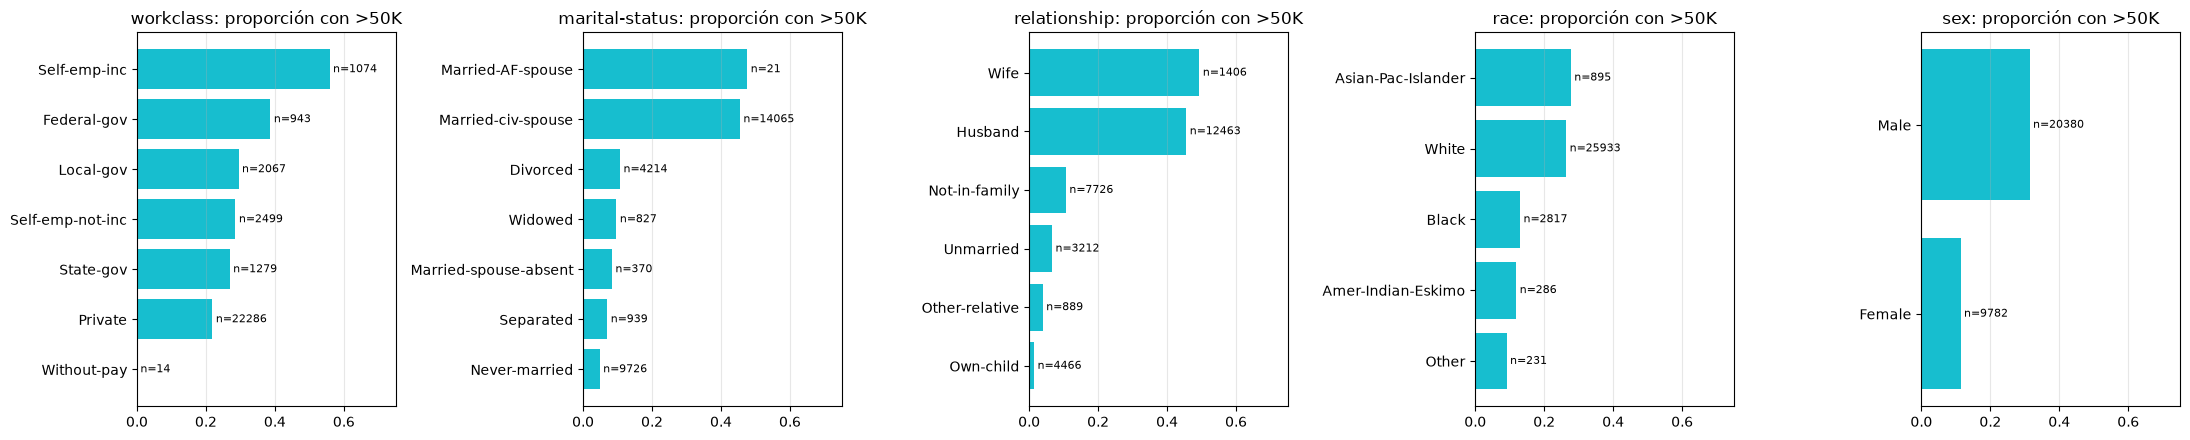

In [5]:
def tasa_por_categoria(col, orden=None):
    g = train_df.groupby(col)["y"].agg(["mean", "size"])
    return g.loc[orden] if orden is not None else g.sort_values("mean")

BAJA_CARDINALIDAD = ["workclass", "marital-status", "relationship", "race", "sex"]
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for ax, c in zip(axes, BAJA_CARDINALIDAD):
    g = tasa_por_categoria(c)
    ax.barh(g.index, g["mean"], color="tab:cyan")
    for i, (m, n) in enumerate(zip(g["mean"], g["size"])):
        ax.text(m + 0.01, i, f"n={n}", va="center", fontsize=8)
    ax.set_title(f"{c}: proporción con >50K"); ax.set_xlim(0, 0.75); ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

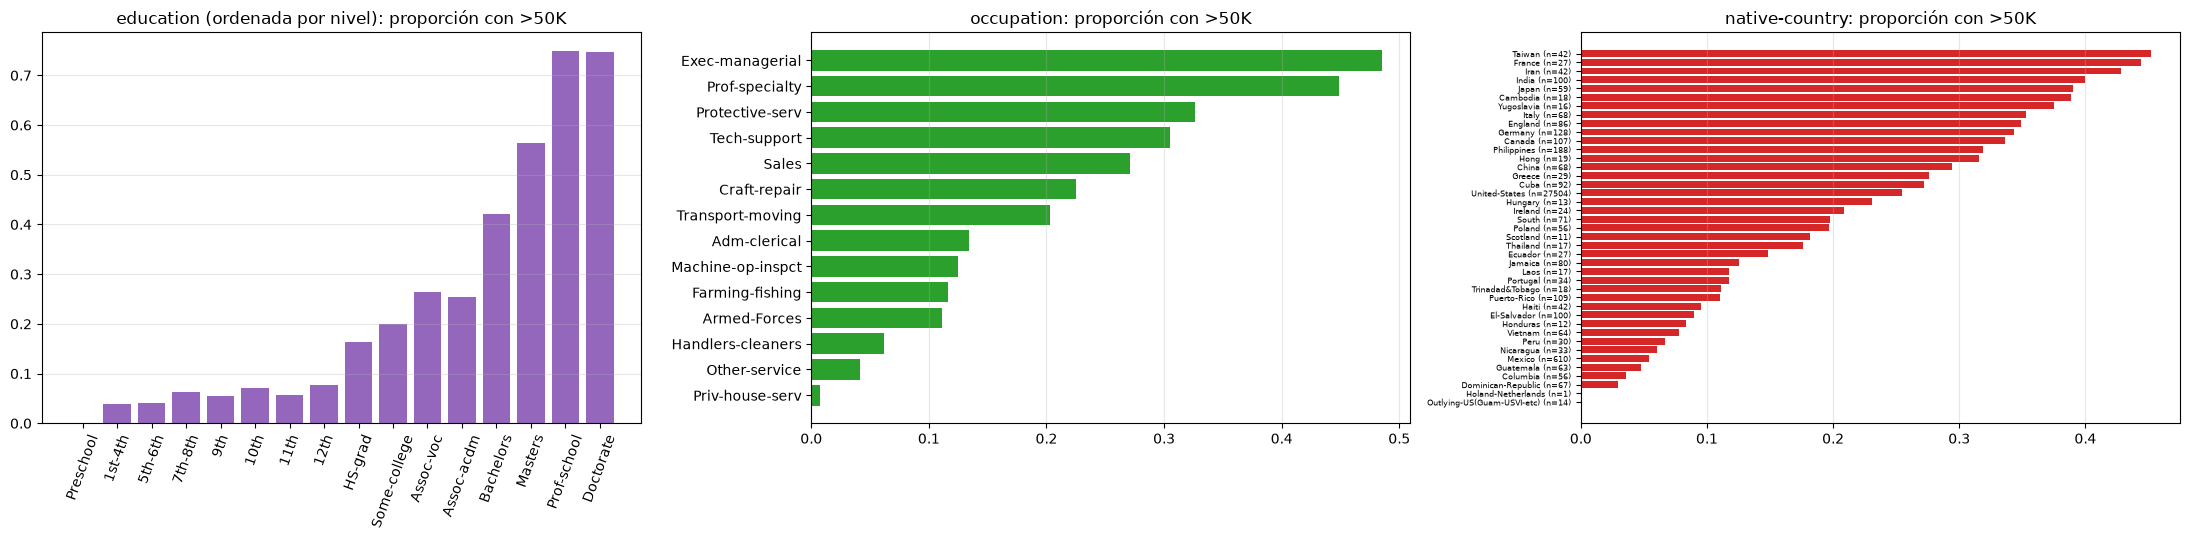

occupation: de 0.7% (Priv-house-serv) a 48.5% (Exec-managerial)
países con menos de 20 filas: 11


In [6]:
EDUCACION_ORDEN = ["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
                   "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters",
                   "Prof-school", "Doctorate"]

fig, axes = plt.subplots(1, 3, figsize=(22, 5.5))
g = tasa_por_categoria("education", orden=EDUCACION_ORDEN)
axes[0].bar(range(len(g)), g["mean"], color="tab:purple")
axes[0].set_xticks(range(len(g))); axes[0].set_xticklabels(g.index, rotation=70)
axes[0].set_title("education (ordenada por nivel): proporción con >50K"); axes[0].grid(alpha=0.3, axis="y")

g = tasa_por_categoria("occupation")
axes[1].barh(g.index, g["mean"], color="tab:green")
axes[1].set_title("occupation: proporción con >50K"); axes[1].grid(alpha=0.3, axis="x")

g = tasa_por_categoria("native-country")
axes[2].barh(range(len(g)), g["mean"], color="tab:red")
axes[2].set_yticks(range(len(g))); axes[2].set_yticklabels([f"{p} (n={n})" for p, n in zip(g.index, g["size"])], fontsize=6)
axes[2].set_title("native-country: proporción con >50K"); axes[2].grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

ocup = tasa_por_categoria("occupation")
print(f"occupation: de {ocup['mean'].iloc[0]:.1%} ({ocup.index[0]}) a {ocup['mean'].iloc[-1]:.1%} ({ocup.index[-1]})")
print("países con menos de 20 filas:", int((g["size"] < 20).sum()))

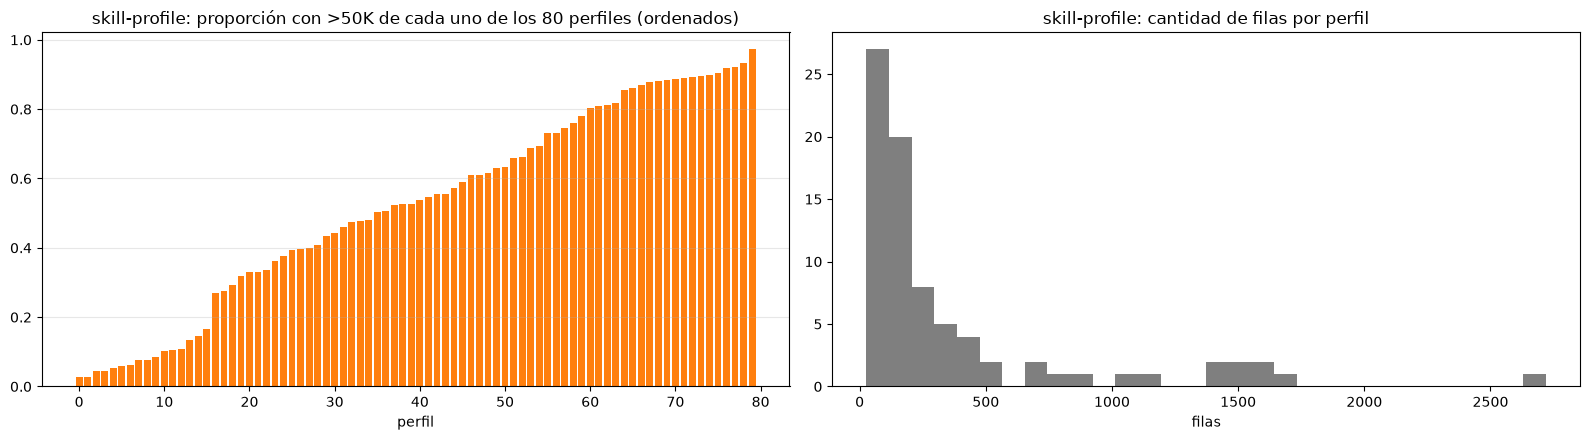

% con >50K según el perfil: mínimo 2.7%, máximo 97.3%
filas por perfil: mínimo 26, mediana 159, máximo 2720
ocupaciones distintas por perfil (promedio): 9.9

Los 10 perfiles con menor y mayor proporción de >50K:


,proporción con >50K,filas
skill-profile,,
food_service_kitchen_basic,0.027,1668
agriculture_field_work,0.029,1638
maintenance_janitorial,0.044,1610
personal_care_assistance,0.045,775
caregiving_home_support,0.052,693
logistics_warehouse_basic,0.060,1465
customer_service_retail,0.061,2720
customer_service_hospitality,0.077,1452
office_data_entry_basic,0.077,1021


In [7]:
g = tasa_por_categoria("skill-profile")
por_ocupacion = pd.crosstab(train_df["skill-profile"], train_df["occupation"])

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
axes[0].bar(range(len(g)), g["mean"], color="tab:orange")
axes[0].set_title("skill-profile: proporción con >50K de cada uno de los 80 perfiles (ordenados)")
axes[0].set_xlabel("perfil"); axes[0].grid(alpha=0.3, axis="y")
axes[1].hist(g["size"], bins=30, color="tab:gray")
axes[1].set_title("skill-profile: cantidad de filas por perfil"); axes[1].set_xlabel("filas")
plt.tight_layout(); plt.show()

print(f"% con >50K según el perfil: mínimo {g['mean'].min():.1%}, máximo {g['mean'].max():.1%}")
print(f"filas por perfil: mínimo {g['size'].min()}, mediana {int(g['size'].median())}, máximo {g['size'].max()}")
print(f"ocupaciones distintas por perfil (promedio): {(por_ocupacion > 0).sum(axis=1).mean():.1f}")
tabla_perfiles = g.rename(columns={"mean": "proporción con >50K", "size": "filas"}).round(3)
print("\nLos 10 perfiles con menor y mayor proporción de >50K:")
display(pd.concat([tabla_perfiles.head(10), tabla_perfiles.tail(10)]))

Con el criterio del enunciado (10 o más valores únicos = alta cardinalidad) quedan cinco variables de baja cardinalidad (sex, race, relationship, workclass y marital-status) y cuatro de alta: occupation (14), education (16), native-country (41) y skill-profile (80). Cada una tiene sus particularidades:

- Las de baja cardinalidad muestran diferencias claras en la tasa de >50K. Los casados (Husband/Wife, Married-civ-spouse) rondan el 45-50%, contra menos del 10% de los que nunca se casaron o viven con los padres. También self-emp-inc contra private, y hombres contra mujeres (31% contra 11%). Algunas categorías son muy chicas (Without-pay tiene 14 filas, Married-AF-spouse 21). Para un one-hot eso casi no agrega columnas, aunque la red tiene muy pocos ejemplos para aprender algo propio de esas categorías.
- education es de alta cardinalidad pero tiene un orden natural, y la tasa de >50K sube casi monótonamente con el nivel: arranca en 0% en Preschool, llega al 42% en Bachelors y al 75% en Prof-school y Doctorate. Hay algún escalón no del todo monótono (11th queda por debajo de 10th, Assoc-acdm apenas por debajo de Assoc-voc), pero la tendencia es muy clara.
- occupation va del 0,7% (Priv-house-serv) al 48,5% (Exec-managerial). No tiene un orden intrínseco: Sales no está "entre" Tech-support y Craft-repair en ningún sentido.
- native-country está muy concentrada: United-States es el 91,2% de las filas, y 39 de los 41 países tienen menos del 1% de los datos. 11 tienen menos de 20 filas y Holand-Netherlands tiene una sola. Las tasas de >50K de los países chicos (Taiwán 45%, Guatemala 5%) son muy ruidosas justamente por eso.
- skill-profile es la más interesante. Sus 80 perfiles van desde el 2,7% hasta el 97,3% de >50K, el rango más amplio de todas las categóricas. La cantidad de filas por perfil es muy despareja (de 26 a 2720, mediana 159), y en la tabla se ve que los perfiles con las proporciones más altas son de los más chicos (entre 37 y 171 filas), así que esas tasas extremas son también las más ruidosas. Nos preguntamos si no sería una subdivisión de occupation, pero cada perfil aparece en promedio en 9,9 ocupaciones distintas, así que no es simplemente un detalle de la ocupación. Cuánto aporta a la predicción por encima de occupation no lo medimos.

### Decisión final para cada variable

| Variable | Tipo / cardinalidad | Transformación | Por qué |
|---|---|---|---|
| age | numérica | estandarización | distribución razonable, solo hay que llevarla a una escala comparable |
| hours-per-week | numérica | estandarización | idem |
| capital-gain | numérica, 91,6% ceros, muy asimétrica | log1p + estandarización | comprimir la cola sin perder el 99999, que es informativo |
| capital-loss | numérica, 95,3% ceros, muy asimétrica | log1p + estandarización | idem |
| sex | categórica, 2 valores | binaria (Male = 1) | con dos valores una sola columna alcanza |
| race | categórica, 5 valores | one-hot | sin orden, pocas categorías: agrega 5 columnas |
| relationship | categórica, 6 valores | one-hot | sin orden, 6 columnas |
| workclass | categórica, 7 valores | one-hot | sin orden, 7 columnas |
| marital-status | categórica, 7 valores | one-hot | sin orden, 7 columnas |
| education | categórica, 16 valores (alta) | ordinal 0-15 + estandarización | tiene un orden natural que coincide con la tasa de >50K |
| occupation | categórica, 14 valores (alta) | embedding de dimensión 2 | sin orden y alta cardinalidad |
| native-country | categórica, 41 valores (alta) | embedding de dimensión 3 | sin orden, muchos países con muy pocos datos |
| skill-profile | categórica, 80 valores (alta) | embedding de dimensión 3 | sin orden, la de mayor cardinalidad y la de asociación más marcada con el target |

Algunas aclaraciones sobre estas decisiones:

Para las nominales de baja cardinalidad descartamos el label encoding, porque le asignaría a cada categoría un número (Private = 3, State-gov = 5...) y la red lo interpretaría como un orden y una distancia que no existen. El one-hot no inventa ese orden y, con 25 columnas en total para las cuatro variables, es barato. No les pusimos embeddings porque con 5-7 categorías no hay mucho para comprimir.

education es la excepción entre las de alta cardinalidad: no le ponemos un embedding aunque tenga 16 valores. El enunciado habla de decidir según cardinalidad, contexto y orden interno, y acá el orden pesa más. Con un ordinal, la red recibe en una sola columna la información "más estudio implica, en general, más ingreso", mientras que un embedding tendría que descubrir ese orden desde cero. El costo es que el ordinal asume que todos los escalones son iguales (de 9th a 10th igual que de Masters a Prof-school), pero la red tiene capas ocultas con ReLU, así que puede deformar esa escala si le hace falta.

Para occupation, native-country y skill-profile usamos embeddings: son nominales y de alta cardinalidad, y un embedding le da a cada categoría un vector chico que se aprende junto con la red. Así, categorías con comportamiento parecido pueden quedar cerca, y las que tienen pocos datos no necesitan su propio bloque de pesos en la primera capa. occupation, con 14 valores, está en el límite: un one-hot también habría sido razonable. La incluimos porque cumple el criterio de alta cardinalidad y porque no tiene orden. Cómo elegimos las dimensiones está justificado en el punto b).

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

In [8]:
ONE_HOT = ["workclass", "marital-status", "relationship", "race"]
EMBEDDING = ["occupation", "native-country", "skill-profile"]
CON_LOG = ["capital-gain", "capital-loss"]
A_ESTANDARIZAR = NUMERICAS + ["education"]

def preparar_densas(df, columnas_one_hot):
    cols = {}
    for c in NUMERICAS:
        cols[c] = np.log1p(df[c]) if c in CON_LOG else df[c]
    cols["education"] = df["education"].map({e: i for i, e in enumerate(EDUCACION_ORDEN)})
    cols["sex"] = (df["sex"] == "Male").astype(int)
    for c in columnas_one_hot:
        for v in sorted(train_df[c].unique()):           # las categorías se toman solo de train
            cols[f"{c}={v}"] = (df[c] == v).astype(int)
    return pd.DataFrame(cols, index=df.index).astype(float)

def estandarizar(X_tr, X_va):
    media, desvio = X_tr[A_ESTANDARIZAR].mean(), X_tr[A_ESTANDARIZAR].std()   # estadísticas de train
    X_tr, X_va = X_tr.copy(), X_va.copy()
    X_tr[A_ESTANDARIZAR] = (X_tr[A_ESTANDARIZAR] - media) / desvio
    X_va[A_ESTANDARIZAR] = (X_va[A_ESTANDARIZAR] - media) / desvio
    return X_tr, X_va

# Índices consecutivos para cada variable que va a un embedding
indice_de = {c: {v: i for i, v in enumerate(sorted(train_df[c].unique()))} for c in EMBEDDING}
cardinalidades = [len(indice_de[c]) for c in EMBEDDING]

Xtr_b, Xva_b = estandarizar(preparar_densas(train_df, ONE_HOT), preparar_densas(val_df, ONE_HOT))
idx_tr = np.stack([train_df[c].map(indice_de[c]).values for c in EMBEDDING], axis=1)
idx_va = np.stack([val_df[c].map(indice_de[c]).values for c in EMBEDDING], axis=1)
y_tr = (train_df["income"] == ">50K").astype(np.float32).values
y_va = (val_df["income"] == ">50K").astype(np.float32).values

print("features densas:", Xtr_b.shape[1], "| variables con embedding:", dict(zip(EMBEDDING, cardinalidades)))

features densas: 31 | variables con embedding: {'occupation': 14, 'native-country': 41, 'skill-profile': 80}


In [9]:
class DatasetCenso(Dataset):
    def __init__(self, x, idx, y):
        self.x = torch.tensor(np.asarray(x), dtype=torch.float32)
        self.idx = torch.tensor(np.asarray(idx), dtype=torch.long)
        self.y = torch.tensor(np.asarray(y), dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.x[i], self.idx[i], self.y[i]


class RedCenso(nn.Module):
    # Si dims_embedding está vacío, la red es la misma pero sin embeddings (todo entra como columnas densas)
    def __init__(self, n_densas, cardinalidades, dims_embedding, capas, p_dropout):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(n, d) for n, d in zip(cardinalidades, dims_embedding)])
        bloques, entrada = [], n_densas + sum(dims_embedding)
        for neuronas in capas:
            bloques += [nn.Linear(entrada, neuronas), nn.ReLU()]
            if p_dropout > 0:
                bloques.append(nn.Dropout(p_dropout))
            entrada = neuronas
        bloques.append(nn.Linear(entrada, 1))          # un logit: la sigmoide la aplica BCEWithLogitsLoss
        self.mlp = nn.Sequential(*bloques)

    def forward(self, x, idx):
        if len(self.embeddings) > 0:
            x = torch.cat([x] + [emb(idx[:, i]) for i, emb in enumerate(self.embeddings)], dim=1)
        return self.mlp(x).squeeze(1)


def evaluar(modelo, x, idx, y):
    modelo.eval()
    with torch.no_grad():
        logits = modelo(x.to(device), idx.to(device)).cpu()
    pred = (logits > 0).numpy().astype(int)
    return pred, accuracy_score(y, pred), f1_score(y, pred, average="macro")


def entrenar(X_tr, I_tr, X_va, I_va, dims_embedding, p_dropout, seed, epocas=40, capas=(128, 64, 32), lr=1e-3, batch=256):
    torch.manual_seed(seed)
    modelo = RedCenso(X_tr.shape[1], cardinalidades if dims_embedding else [], dims_embedding, capas, p_dropout).to(device)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    perdida = nn.BCEWithLogitsLoss()
    ds_tr, ds_va = DatasetCenso(X_tr, I_tr, y_tr), DatasetCenso(X_va, I_va, y_va)
    loader = DataLoader(ds_tr, batch_size=batch, shuffle=True, generator=torch.Generator().manual_seed(seed))
    hist = {"acc_train": [], "acc_val": [], "f1_train": [], "f1_val": []}
    for _ in range(epocas):
        modelo.train()
        for xb, ib, yb in loader:
            optimizador.zero_grad()
            perdida(modelo(xb.to(device), ib.to(device)), yb.to(device)).backward()
            optimizador.step()
        _, acc_tr, f1_tr = evaluar(modelo, ds_tr.x, ds_tr.idx, y_tr)
        _, acc_va, f1_va = evaluar(modelo, ds_va.x, ds_va.idx, y_va)
        for k, v in zip(hist, (acc_tr, acc_va, f1_tr, f1_va)):
            hist[k].append(v)
    return modelo, hist

#### Dimensión de los embeddings

No hay una fórmula exacta para elegir la dimensión de un embedding, pero sí algunas reglas prácticas. Probamos tres, de más chica a más grande:

- Raíz cuarta de la cantidad de categorías, la regla que propone Google en la guía de feature columns de TensorFlow [1]. Da dimensiones 2, 3 y 3.
- 1,6 · n^0,56, la regla que usa por defecto fast.ai para datos tabulares, con un máximo de 600 que acá no influye [2]. Da 7, 13 y 19.
- n/2 con un tope de 50, como tercera alternativa bastante más grande que las otras dos: 7, 20 y 40.

Entrenamos la red completa (la misma arquitectura que usamos abajo, con dropout) con cada opción y con tres semillas distintas, y comparamos el F1 macro de validation.

,regla,"dimensiones (occupation, country, skill)",parámetros de los embeddings,"F1 macro val, mejor época (media 3 semillas)","F1 macro val, última época (media 3 semillas)",desvío entre semillas (última época)
0,raíz cuarta de n,"[2, 3, 3]",391,0.8476,0.8448,0.0015
1,"1,6 · n^0,56","[7, 13, 19]",2151,0.8428,0.8359,0.0005
2,n/2 (con tope 50),"[7, 20, 40]",4118,0.8453,0.8341,0.0032


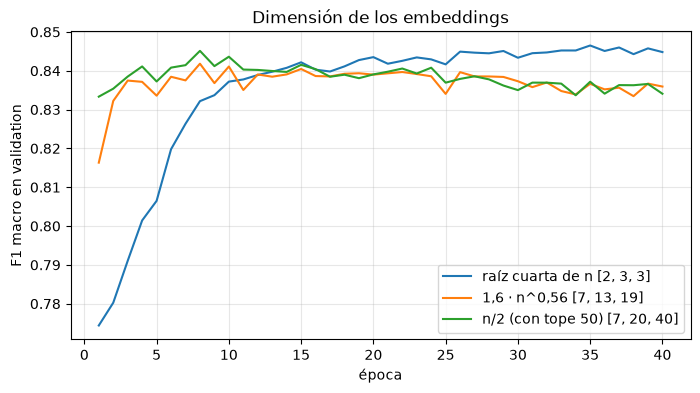

In [10]:
REGLAS = {
    "raíz cuarta de n":   [round(n ** 0.25) for n in cardinalidades],
    "1,6 · n^0,56":       [round(1.6 * n ** 0.56) for n in cardinalidades],
    "n/2 (con tope 50)":  [min(50, n // 2) for n in cardinalidades],
}
filas, curvas = [], {}
for nombre, dims in REGLAS.items():
    hists = [entrenar(Xtr_b, idx_tr, Xva_b, idx_va, dims, p_dropout=0.3, seed=s)[1] for s in (0, 1, 2)]
    f1v = np.array([h["f1_val"] for h in hists])
    curvas[nombre] = f1v.mean(axis=0)
    filas.append({"regla": nombre, "dimensiones (occupation, country, skill)": dims,
                  "parámetros de los embeddings": sum(n * d for n, d in zip(cardinalidades, dims)),
                  "F1 macro val, mejor época (media 3 semillas)": f1v.max(axis=1).mean(),
                  "F1 macro val, última época (media 3 semillas)": f1v[:, -1].mean(),
                  "desvío entre semillas (última época)": f1v[:, -1].std()})
tabla_dims = pd.DataFrame(filas).round(4)
display(tabla_dims)

plt.figure(figsize=(8, 4))
for nombre, c in curvas.items():
    plt.plot(range(1, len(c) + 1), c, label=f"{nombre} {REGLAS[nombre]}")
plt.xlabel("época"); plt.ylabel("F1 macro en validation"); plt.title("Dimensión de los embeddings")
plt.legend(); plt.grid(alpha=0.3); plt.show()

Ganó la regla más chica, la raíz cuarta, tanto en la mejor época (0,8476 de F1 macro promedio) como en la última (0,8448). Además usa diez veces menos parámetros en los embeddings que n/2 (391 contra 4118). En el gráfico se ve que las dimensiones grandes arrancan mucho más rápido: a las pocas épocas ya están cerca de 0,84, porque tienen más capacidad para separar categorías. Pero se estancan alrededor de la época 8 y después bajan de a poco, que es lo que esperaríamos si están memorizando las categorías. Con dimensiones 2-3 la red tarda unas 10 épocas en ponerse al día y después sigue mejorando hasta el final.

Creemos que tiene sentido que alcance con tan pocas dimensiones. Para predecir el ingreso, lo principal de cada ocupación, país o perfil es "qué tan asociado está a ingresos altos", más algún matiz. Eso entra en 2 o 3 números. Nuestra hipótesis es que dar más espacio le deja lugar a la red para aprenderse el ruido de las categorías chicas, y es compatible con cómo caen las curvas de las dimensiones grandes. Nos quedamos entonces con dimensiones 2 (occupation), 3 (native-country) y 3 (skill-profile).

Una aclaración honesta: las diferencias entre reglas son chicas (del orden de 0,005 en la mejor época; en la última época son de 0,009 a 0,011, varias veces el desvío entre semillas) y las medimos en el mismo set de validation que después usamos para reportar. Como el TP solo nos da train y validation, lo aceptamos, pero los números finales pueden quedar levemente optimistas.

#### Modelo final

- Arquitectura: tres capas ocultas de 128, 64 y 32 neuronas con ReLU, y dropout de 0,3 después de cada capa oculta. La entrada son las 31 columnas densas más los 8 valores de los tres embeddings (2 + 3 + 3), concatenados con `torch.cat`, o sea 39 entradas a la primera capa.
- Salida: una sola neurona con el logit. Como el problema es binario, usamos `BCEWithLogitsLoss`, que es la Binary CrossEntropy con la sigmoide incluida. Es numéricamente más estable que poner una sigmoide y después `BCELoss`. Para predecir, un logit > 0 equivale a probabilidad > 0,5.
- Optimizador: Adam con lr = 1e-3, batches de 256 y 40 épocas.

Reportamos los dos modelos tal como quedan al terminar las 40 épocas, para compararlos con el mismo presupuesto de entrenamiento y que se vea cómo evoluciona cada uno. También mostramos el mejor F1 que alcanzan en el camino, pero sin volver a ese punto del entrenamiento. Como validation ya lo usamos para elegir las dimensiones, estas métricas no reemplazan una evaluación en un test independiente.

RedCenso(
  (embeddings): ModuleList(
    (0): Embedding(14, 2)
    (1): Embedding(41, 3)
    (2): Embedding(80, 3)
  )
  (mlp): Sequential(
    (0): Linear(in_features=39, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

parámetros entrenables: 15880


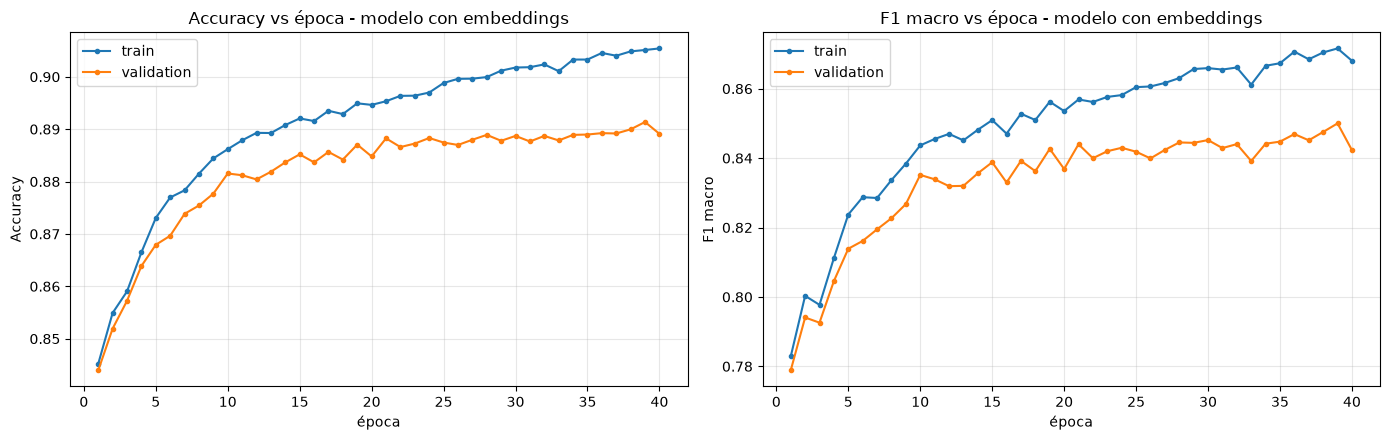

F1 macro val: mejor 0.8500 en la época 39 | última época 0.8423
F1 macro train en la última época: 0.8681
accuracy val: máxima 0.8914 | última época 0.8891 | accuracy train última época 0.9054


In [11]:
DIMS = REGLAS["raíz cuarta de n"]
CAPAS = (128, 64, 32)
EPOCAS = 40

modelo_b, hist_b = entrenar(Xtr_b, idx_tr, Xva_b, idx_va, DIMS, p_dropout=0.3, seed=SEED, epocas=EPOCAS, capas=CAPAS)
print(modelo_b)
print("\nparámetros entrenables:", sum(p.numel() for p in modelo_b.parameters()))

def graficar_curvas(hist, titulo):
    ep = range(1, len(hist["acc_train"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, m, nombre in [(axes[0], "acc", "Accuracy"), (axes[1], "f1", "F1 macro")]:
        ax.plot(ep, hist[f"{m}_train"], label="train", marker=".")
        ax.plot(ep, hist[f"{m}_val"], label="validation", marker=".")
        ax.set_xlabel("época"); ax.set_ylabel(nombre); ax.set_title(f"{nombre} vs época - {titulo}")
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

graficar_curvas(hist_b, "modelo con embeddings")
mejor = int(np.argmax(hist_b["f1_val"]))
print(f"F1 macro val: mejor {hist_b['f1_val'][mejor]:.4f} en la época {mejor + 1} | última época {hist_b['f1_val'][-1]:.4f}")
print(f"F1 macro train en la última época: {hist_b['f1_train'][-1]:.4f}")
print(f"accuracy val: máxima {max(hist_b['acc_val']):.4f} | última época {hist_b['acc_val'][-1]:.4f} | accuracy train última época {hist_b['acc_train'][-1]:.4f}")

              precision    recall  f1-score   support

       <=50K     0.9070    0.9504    0.9282     11360
        >50K     0.8216    0.7008    0.7564      3700

    accuracy                         0.8891     15060
   macro avg     0.8643    0.8256    0.8423     15060
weighted avg     0.8860    0.8891    0.8860     15060



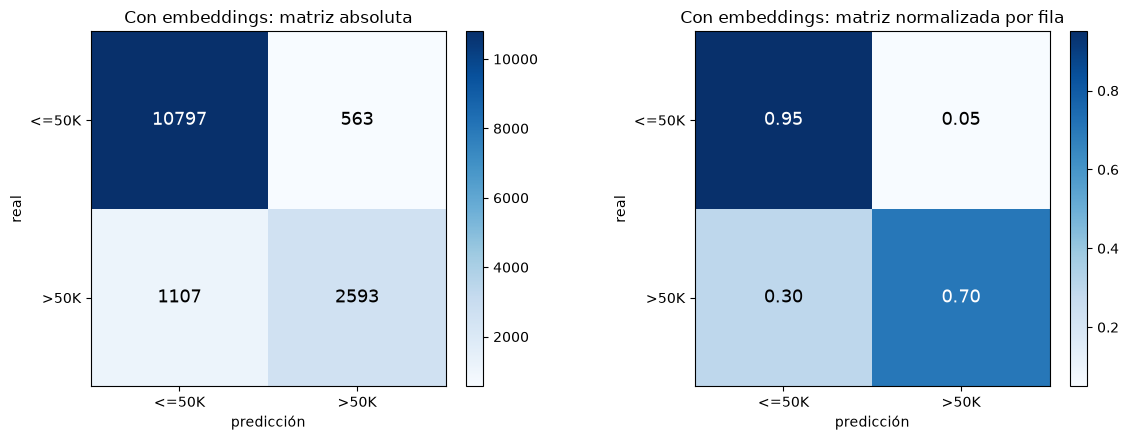

In [12]:
def graficar_confusion(y_real, y_pred, titulo):
    etiquetas = ["<=50K", ">50K"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, normalizar, nombre in [(axes[0], None, "absoluta"), (axes[1], "true", "normalizada por fila")]:
        cm = confusion_matrix(y_real, y_pred, normalize=normalizar)
        im = ax.imshow(cm, cmap="Blues")
        for i in range(2):
            for j in range(2):
                texto = f"{cm[i, j]:.2f}" if normalizar else f"{cm[i, j]:d}"
                ax.text(j, i, texto, ha="center", va="center", fontsize=13,
                        color="white" if cm[i, j] > cm.max() / 2 else "black")
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(etiquetas); ax.set_yticklabels(etiquetas)
        ax.set_xlabel("predicción"); ax.set_ylabel("real"); ax.set_title(f"{titulo}: matriz {nombre}")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

ds_va_b = DatasetCenso(Xva_b, idx_va, y_va)
pred_b, acc_b, f1_b = evaluar(modelo_b, ds_va_b.x, ds_va_b.idx, y_va)
print(classification_report(y_va, pred_b, target_names=["<=50K", ">50K"], digits=4))
graficar_confusion(y_va, pred_b, "Con embeddings")

Las curvas de train y validation suben juntas. A partir de la época 20 validation se estabiliza alrededor de 0,84-0,85 de F1 macro y 0,885-0,89 de accuracy, mientras train sigue subiendo despacio. En la época 40 la brecha de F1 macro entre train y validation es de 0,026, lo que muestra un sobreajuste leve. El mejor F1 de validation fue 0,8500 en la época 39, y en la 40 quedó en 0,8423. Esa caída es compatible con las fluctuaciones que se ven en el gráfico, donde la curva de validation sube y baja casi 0,01 entre épocas consecutivas. Una sola caída no alcanza para hablar de una tendencia.

En la época 40 el modelo tiene 88,9% de accuracy y 0,842 de F1 macro. Por clase:

- <=50K: F1 de 0,928, con recall de 0,95 (de 11.360 personas, clasifica mal 563).
- >50K: F1 de 0,756, con precision de 0,82 pero recall de 0,70. De las 3700 personas que ganan más de 50K, 1107 quedan clasificadas como <=50K.

O sea que el error dominante son los falsos negativos de la clase minoritaria. Es lo esperable con un 25% de positivos y umbral 0,5: ante la duda, la red se inclina por la clase mayoritaria. Si interesara detectar más >50K se podría bajar el umbral o usar `pos_weight` en la loss, a costa de más falsos positivos. No lo hicimos porque la consigna no lo pide y queríamos comparar los dos modelos en las mismas condiciones.

Como extra, miramos qué aprendió el embedding de skill-profile.

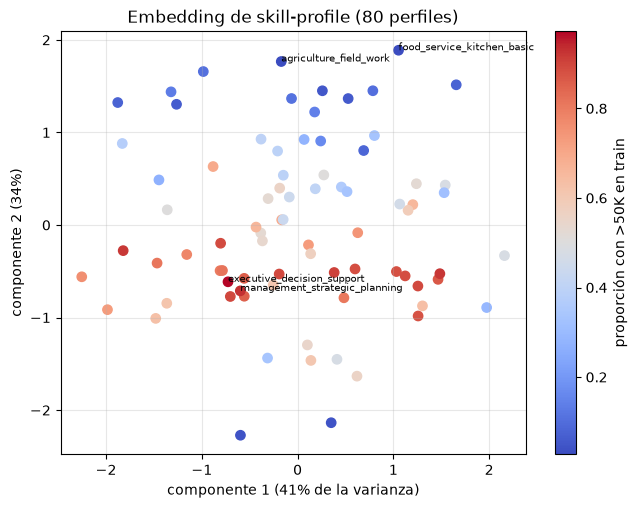

correlación con el % de >50K del perfil: componente 1 = -0.065 | componente 2 = -0.574


In [13]:
# ¿Qué aprendió el embedding de skill-profile? Proyectamos sus 3 dimensiones a 2 con PCA
pesos = modelo_b.embeddings[EMBEDDING.index("skill-profile")].weight.detach().cpu().numpy()
centrados = pesos - pesos.mean(axis=0)
_, valores_s, componentes = np.linalg.svd(centrados, full_matrices=False)
proyeccion = centrados @ componentes[:2].T
varianza = (valores_s ** 2) / (valores_s ** 2).sum()

perfiles = sorted(indice_de["skill-profile"], key=indice_de["skill-profile"].get)
tasa = train_df.groupby("skill-profile")["y"].mean().loc[perfiles].values
correlaciones = [np.corrcoef(proyeccion[:, k], tasa)[0, 1] for k in range(2)]

plt.figure(figsize=(7.5, 5.5))
sc = plt.scatter(proyeccion[:, 0], proyeccion[:, 1], c=tasa, cmap="coolwarm", s=45)
plt.colorbar(sc, label="proporción con >50K en train")
for k in np.argsort(tasa)[[0, 1, -2, -1]]:
    plt.annotate(perfiles[k], proyeccion[k], fontsize=7)
plt.xlabel(f"componente 1 ({varianza[0]:.0%} de la varianza)"); plt.ylabel(f"componente 2 ({varianza[1]:.0%})")
plt.title("Embedding de skill-profile (80 perfiles)"); plt.grid(alpha=0.3); plt.show()
print(f"correlación con el % de >50K del perfil: componente 1 = {correlaciones[0]:.3f} | componente 2 = {correlaciones[1]:.3f}")

No le pasamos a la red la proporción de >50K de cada perfil como dato. Sí aprendió a partir de las etiquetas de cada persona, así que no es que "descubrió" algo que no tenía, pero es interesante ver cómo quedó organizado el embedding. En la componente 2 del gráfico, los perfiles de ingresos bajos (azules, como food_service_kitchen_basic o agriculture_field_work) tienden a quedar arriba y los de ingresos altos (rojos, como executive_decision_support o management_strategic_planning) abajo, con una correlación de -0,57 entre esa componente y la proporción en train. Es una asociación moderada: el embedding no reproduce la tasa, pero sí captura información relacionada con el ingreso. La componente 1 casi no se relaciona con la tasa (-0,07). Suponemos que captura algo que la red usa en combinación con otras variables, pero no nos animamos a interpretarla.

Es lo que esperábamos de un embedding: que perfiles parecidos en lo que importa para el problema queden cerca. Que eso ayude en particular a los perfiles con pocos datos es una hipótesis razonable, pero no la medimos por separado.

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.

features densas: 166 (las 31 de antes + 135 columnas one-hot de ['occupation', 'native-country', 'skill-profile'])


RedCenso(
  (embeddings): ModuleList()
  (mlp): Sequential(
    (0): Linear(in_features=166, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

parámetros entrenables: 31745


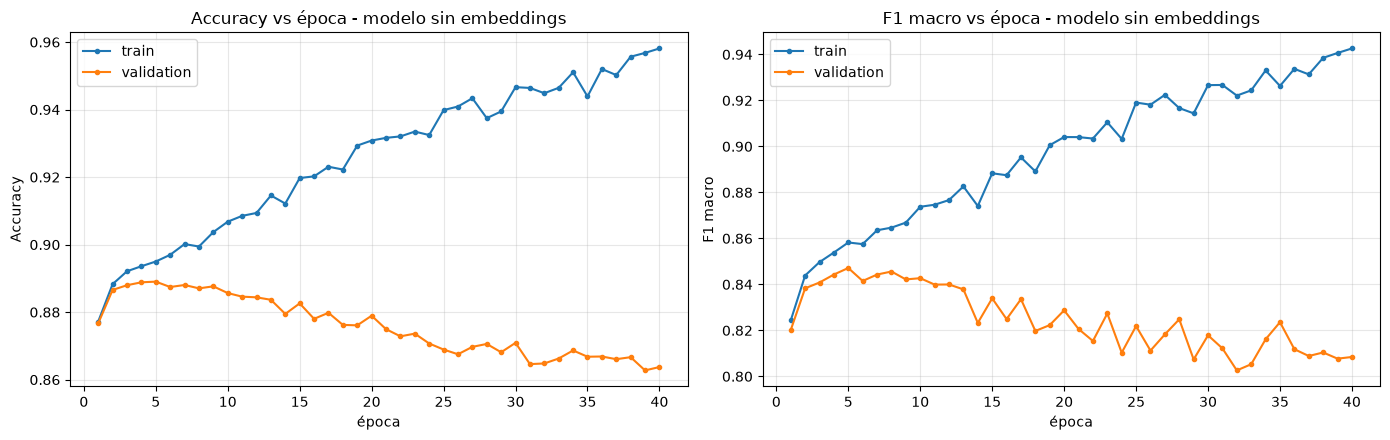

F1 macro val: mejor 0.8471 en la época 5 | última época 0.8084
F1 macro train en la última época: 0.9426
accuracy val: máxima 0.8890 | última época 0.8637 | accuracy train última época 0.9581


In [14]:
Xtr_c, Xva_c = estandarizar(preparar_densas(train_df, ONE_HOT + EMBEDDING), preparar_densas(val_df, ONE_HOT + EMBEDDING))
print("features densas:", Xtr_c.shape[1], f"(las {Xtr_b.shape[1]} de antes + {sum(cardinalidades)} columnas one-hot de {EMBEDDING})")

modelo_c, hist_c = entrenar(Xtr_c, idx_tr, Xva_c, idx_va, [], p_dropout=0.0, seed=SEED, epocas=EPOCAS, capas=CAPAS)
print(modelo_c)
print("\nparámetros entrenables:", sum(p.numel() for p in modelo_c.parameters()))

graficar_curvas(hist_c, "modelo sin embeddings")
mejor = int(np.argmax(hist_c["f1_val"]))
print(f"F1 macro val: mejor {hist_c['f1_val'][mejor]:.4f} en la época {mejor + 1} | última época {hist_c['f1_val'][-1]:.4f}")
print(f"F1 macro train en la última época: {hist_c['f1_train'][-1]:.4f}")
print(f"accuracy val: máxima {max(hist_c['acc_val']):.4f} | última época {hist_c['acc_val'][-1]:.4f} | accuracy train última época {hist_c['acc_train'][-1]:.4f}")

              precision    recall  f1-score   support

       <=50K     0.8947    0.9287    0.9114     11360
        >50K     0.7521    0.6643    0.7055      3700

    accuracy                         0.8637     15060
   macro avg     0.8234    0.7965    0.8084     15060
weighted avg     0.8597    0.8637    0.8608     15060



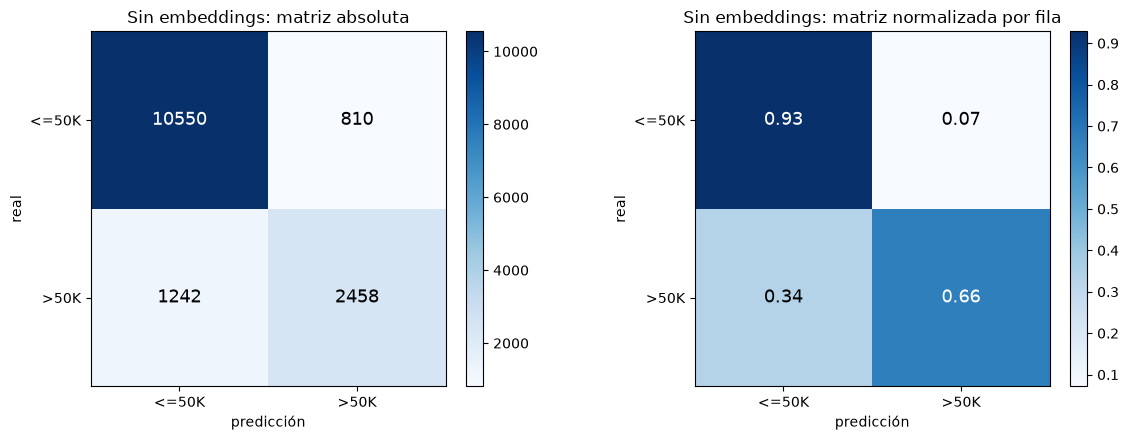

In [15]:
ds_va_c = DatasetCenso(Xva_c, idx_va, y_va)
pred_c, acc_c, f1_c = evaluar(modelo_c, ds_va_c.x, ds_va_c.idx, y_va)
print(classification_report(y_va, pred_c, target_names=["<=50K", ">50K"], digits=4))
graficar_confusion(y_va, pred_c, "Sin embeddings")

Este modelo tiene exactamente las mismas capas (128-64-32 con ReLU y una salida), pero sin dropout, y occupation, native-country y skill-profile entran como one-hot: 14 + 41 + 80 = 135 columnas más, 166 entradas en total. Solo la primera capa ya tiene 21.376 parámetros, más que todo el modelo con embeddings.

Las curvas muestran un sobreajuste marcado. El F1 macro de validation llega a su máximo muy temprano (0,8471 en la época 5, casi igual al modelo con embeddings) y a partir de ahí baja de forma sostenida, mientras que el de train sigue subiendo hasta 0,943 (con 95,8% de accuracy). En la época 40 la brecha es de 0,134, cinco veces la del modelo b). La accuracy de validation cuenta lo mismo: sube hasta ~0,889 en las primeras épocas y termina en 0,864.

En la época 40 el modelo tiene 86,4% de accuracy y 0,808 de F1 macro. Empeora en las dos clases respecto al modelo b), pero sobre todo en >50K: la precision baja de 0,82 a 0,75 y el recall de 0,70 a 0,66. En la matriz de confusión son 1242 falsos negativos (contra 1107) y 810 falsos positivos (contra 563). O sea que pierde precision y recall a la vez. Incluso predice un poco más de personas como >50K que el modelo b) (3268 contra 3156), pero acierta menos de esos casos y deja escapar más de los reales: distingue peor las dos clases. Es lo esperable en un modelo que se aprendió particularidades de train que no se repiten en validation.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.

In [16]:
def resumen(nombre, modelo, hist, pred, n_entradas):
    n_emb = sum(p.numel() for e in modelo.embeddings for p in e.parameters())
    primera = modelo.mlp[0]
    reporte = classification_report(y_va, pred, output_dict=True)
    return {"modelo": nombre,
            "accuracy val": accuracy_score(y_va, pred),
            "F1 macro val": f1_score(y_va, pred, average="macro"),
            "precision >50K": reporte["1.0"]["precision"], "recall >50K": reporte["1.0"]["recall"],
            "F1 macro val (mejor época)": max(hist["f1_val"]),
            "brecha F1 train - val": hist["f1_train"][-1] - hist["f1_val"][-1],
            "valores de entrada por fila": n_entradas,
            "entrada a la 1ra capa": primera.in_features,
            "parámetros embeddings": n_emb,
            "parámetros 1ra capa": sum(p.numel() for p in primera.parameters()),
            "parámetros totales": sum(p.numel() for p in modelo.parameters())}

tabla_final = pd.DataFrame([
    resumen("b) con embeddings + dropout", modelo_b, hist_b, pred_b, Xtr_b.shape[1] + len(EMBEDDING)),
    resumen("c) one-hot sin dropout", modelo_c, hist_c, pred_c, Xtr_c.shape[1]),
]).set_index("modelo").T
tabla_final.round(4)

modelo,b) con embeddings + dropout,c) one-hot sin dropout
accuracy val,0.8891,0.8637
F1 macro val,0.8423,0.8084
precision >50K,0.8216,0.7521
recall >50K,0.7008,0.6643
F1 macro val (mejor época),0.8500,0.8471
brecha F1 train - val,0.0257,0.1342
valores de entrada por fila,34.0000,166.0000
entrada a la 1ra capa,39.0000,166.0000
parámetros embeddings,391.0000,0.0000
parámetros 1ra capa,5120.0000,21376.0000


En cuanto a tamaño, el modelo con embeddings recibe 34 valores por fila (31 columnas densas más 3 índices enteros, uno por variable con embedding), que se convierten en 39 entradas a la primera capa una vez que se buscan los vectores. El modelo one-hot recibe 166. Esa diferencia está casi toda en la primera capa: las 135 columnas one-hot de las tres variables cuestan 135 × 128 = 17.280 pesos, mientras que con embeddings las mismas tres variables cuestan 391 parámetros de embedding más 8 × 128 = 1024 pesos. En total el modelo b) tiene 15.880 parámetros y el c) 31.745, prácticamente el doble.

En cuanto a desempeño, en la época 40 el modelo b) es mejor en todo: 2,5 puntos más de accuracy (0,889 contra 0,864), 3,4 puntos más de F1 macro (0,842 contra 0,808), y mejor precision y recall para >50K. Pero si miramos la mejor época de cada uno, la diferencia casi desaparece (0,850 contra 0,847). En este experimento, la diferencia no está tanto en el mejor resultado que alcanza cada modelo sino en cuánto lo sostiene.

Hay una sutileza: los modelos b) y c) difieren en dos cosas a la vez (la codificación y el dropout), porque así lo pide la consigna. Para saber cuánto aporta cada una, entrenamos las cuatro combinaciones con tres semillas.

In [17]:
# Los dos modelos difieren en dos cosas a la vez (encoding y dropout). Para separar el efecto de cada una
# entrenamos las cuatro combinaciones, con tres semillas cada una.
variantes = {
    "embeddings + dropout":   (Xtr_b, Xva_b, DIMS, 0.3),
    "embeddings sin dropout": (Xtr_b, Xva_b, DIMS, 0.0),
    "one-hot + dropout":      (Xtr_c, Xva_c, [], 0.3),
    "one-hot sin dropout":    (Xtr_c, Xva_c, [], 0.0),
}
filas = []
for nombre, (Xa, Xb, dims, p) in variantes.items():
    hists = [entrenar(Xa, idx_tr, Xb, idx_va, dims, p_dropout=p, seed=s, epocas=EPOCAS, capas=CAPAS)[1] for s in (0, 1, 2)]
    f1v, f1t = np.array([h["f1_val"] for h in hists]), np.array([h["f1_train"] for h in hists])
    filas.append({"variante": nombre,
                  "F1 val mejor época": f1v.max(axis=1).mean(),
                  "época del mejor": (f1v.argmax(axis=1) + 1).mean(),
                  "F1 val última época": f1v[:, -1].mean(),
                  "desvío F1 val última época": f1v[:, -1].std(),
                  "F1 train última época": f1t[:, -1].mean(),
                  "brecha train - val": (f1t[:, -1] - f1v[:, -1]).mean()})
tabla_ablacion = pd.DataFrame(filas).set_index("variante").round(4)
tabla_ablacion

,F1 val mejor época,época del mejor,F1 val última época,desvío F1 val última época,F1 train última época,brecha train - val
variante,,,,,,
embeddings + dropout,0.8476,35.3333,0.8448,0.0015,0.8730,0.0282
embeddings sin dropout,0.8469,21.6667,0.8343,0.0028,0.8910,0.0567
one-hot + dropout,0.8463,6.3333,0.8317,0.0025,0.9025,0.0708
one-hot sin dropout,0.8466,3.0000,0.8179,0.0039,0.9338,0.1159


#### Qué nos dice la comparación de las cuatro combinaciones

- El mejor F1 es prácticamente el mismo en las cuatro variantes (entre 0,846 y 0,848). En este experimento, las dos codificaciones llegan al mismo nivel en su mejor momento.
- Lo que cambia es cuándo llega ese máximo y cuánto se pierde después. One-hot sin dropout llega al máximo en la época 3 en promedio, one-hot con dropout en la 6, embeddings sin dropout en la 22 y embeddings con dropout en la 35. En la época 40 el F1 de validation queda en 0,818, 0,832, 0,834 y 0,845 respectivamente, y la brecha train-validation va de 0,116 a 0,028.
- Los dos factores ayudan, y en una medida parecida. Pasar de one-hot a embeddings (sin dropout en ninguno de los dos) sube el F1 final 0,016 y baja la brecha de 0,116 a 0,057. Con dropout en los dos, embeddings le saca 0,013 al one-hot. Agregarle dropout al one-hot sube el F1 final 0,014 y baja la brecha a 0,071. Los dos cambios juntos mejoran 0,027 respecto del one-hot sin dropout y dejan la brecha en 0,028 (no es exactamente la suma de los dos efectos). O sea que el embedding, además de representar las categorías, tiene un efecto regularizador por sí mismo.

El modelo b) de arriba (una sola semilla) dio 0,842 en la época 40 y acá el promedio de la misma configuración da 0,845. Esa diferencia es la variabilidad normal entre semillas, y es del mismo orden que las diferencias entre mejores épocas. Por eso no sacamos conclusiones de diferencias de milésimas. En cambio, los desvíos entre semillas del F1 final (de 0,0015 a 0,004) son bastante menores que las diferencias entre variantes en la última época (de 0,013 a 0,027), así que esas sí son consistentes.

#### ¿Y si cortamos el entrenamiento a tiempo?

En la tabla de las cuatro combinaciones se ve que el one-hot llega a su mejor F1 en muy pocas épocas y después empeora. Para ver cuánto de la diferencia entre b) y c) se explica solo por cuándo se corta el entrenamiento, entrenamos los dos modelos otra vez con early stopping. Usamos el mismo criterio que la notebook de CNN: se mira la loss de validation y se corta si pasan 3 épocas sin que mejore al menos un 1% respecto de la mejor, y el modelo queda como está en la época de corte (con 40 épocas como máximo y tres semillas).

Esto no reemplaza a los modelos b) y c) de arriba. La consigna pide que el c) no tenga ningún tipo de regularización, y el early stopping lo es, aunque no sea una capa. Lo usamos solo para entender la comparación.

In [18]:
# Early stopping con el mismo criterio de la notebook de CNN: se mira la loss de validation y se corta
# si pasan 3 épocas sin una mejora relativa de al menos 1%. El modelo queda como está en la época de corte.
def entrenar_con_early_stopping(X_tr, I_tr, X_va, I_va, dims_embedding, p_dropout, seed, paciencia=3,
                                mejora_relativa=0.01, epocas_max=40, capas=(128, 64, 32), lr=1e-3, batch=256):
    torch.manual_seed(seed)
    modelo = RedCenso(X_tr.shape[1], cardinalidades if dims_embedding else [], dims_embedding, capas, p_dropout).to(device)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    perdida = nn.BCEWithLogitsLoss()
    ds_tr, ds_va = DatasetCenso(X_tr, I_tr, y_tr), DatasetCenso(X_va, I_va, y_va)
    loader = DataLoader(ds_tr, batch_size=batch, shuffle=True, generator=torch.Generator().manual_seed(seed))
    mejor_loss, sin_mejora = None, 0
    for epoca in range(1, epocas_max + 1):
        modelo.train()
        for xb, ib, yb in loader:
            optimizador.zero_grad()
            perdida(modelo(xb.to(device), ib.to(device)), yb.to(device)).backward()
            optimizador.step()
        modelo.eval()
        with torch.no_grad():
            loss_val = perdida(modelo(ds_va.x.to(device), ds_va.idx.to(device)), ds_va.y.to(device)).item()
        if mejor_loss is None or loss_val <= mejor_loss * (1 - mejora_relativa):
            mejor_loss, sin_mejora = loss_val, 0
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                break
    _, acc, f1 = evaluar(modelo, ds_va.x, ds_va.idx, y_va)
    return epoca, acc, f1

filas = []
for nombre, (Xa, Xb, dims, p) in [("b) embeddings + dropout", variantes["embeddings + dropout"]),
                                  ("c) one-hot sin dropout", variantes["one-hot sin dropout"])]:
    for s in (0, 1, 2):
        epoca, acc, f1 = entrenar_con_early_stopping(Xa, idx_tr, Xb, idx_va, dims, p_dropout=p, seed=s, epocas_max=EPOCAS, capas=CAPAS)
        filas.append({"modelo": nombre, "semilla": s, "época de corte": epoca, "accuracy val": acc, "F1 macro val": f1})
tabla_es = pd.DataFrame(filas)
display(tabla_es.round(4))
tabla_es.groupby("modelo")[["época de corte", "accuracy val", "F1 macro val"]].mean().round(4)

,modelo,semilla,época de corte,accuracy val,F1 macro val
0,b) embeddings + dropout,0,16,0.8863,0.8431
1,b) embeddings + dropout,1,20,0.8882,0.8444
2,b) embeddings + dropout,2,14,0.8882,0.8421
3,c) one-hot sin dropout,0,6,0.8889,0.8451
4,c) one-hot sin dropout,1,5,0.8880,0.8417
5,c) one-hot sin dropout,2,6,0.8880,0.8445


,época de corte,accuracy val,F1 macro val
modelo,,,
b) embeddings + dropout,16.6667,0.8876,0.8432
c) one-hot sin dropout,5.6667,0.8883,0.8438


Con early stopping, los dos modelos quedan prácticamente empatados: 0,843 de F1 macro para embeddings + dropout y 0,844 para one-hot sin dropout, con accuracy de 0,888 en ambos. La diferencia es menor que la que hay entre semillas del mismo modelo. El one-hot corta en la época 6 en promedio y el de embeddings en la 17.

Esto confirma lo que sugería la comparación de las cuatro variantes: el one-hot sin dropout puede llegar al mismo desempeño, pero solo si se lo frena a tiempo. Sin early stopping, después del máximo tiende a empeorar. El de embeddings, en cambio, es mucho menos sensible a cuándo se corta: en la época 40 tiene prácticamente el mismo F1 que con early stopping. Un detalle: con este criterio el modelo de embeddings corta antes de llegar a su mejor época (que en promedio era la 35). Mejora tan despacio que no llega al 1% que pide el criterio. Un umbral más chico podría retrasar el corte, pero no lo probamos. Además, el criterio mira la loss y nosotros comparamos F1, que no tienen por qué moverse igual.

#### Por qué funcionan mejor los embeddings en este problema

Creemos que la explicación está en las características de las tres variables que codificamos:

1. Muchas categorías tienen pocos datos (39 de los 41 países y 56 de los 80 perfiles tienen menos del 1% de las filas). Con one-hot, cada una de esas categorías tiene sus propios 128 pesos en la primera capa, y la señal para aprenderlos viene solo de las pocas filas donde aparece. Estimar 128 coeficientes propios con tan pocos ejemplos facilita el sobreajuste. Con un embedding de dimensión 2 o 3, en cambio, cada categoría tiene 2 o 3 números y todas comparten los mismos pesos de la primera capa, así que, en principio, lo que la red aprende de un perfil frecuente puede servir para uno parecido pero poco frecuente.
2. El embedding obliga a comprimir. Pasar 80 perfiles por 3 dimensiones fuerza a la red a quedarse con lo esencial (vimos que una de las componentes está asociada a la tasa de >50K) y deja poco espacio para aprender ruido. Es consistente con que las dimensiones grandes hayan sobreajustado más en el experimento de la dimensión.
3. Usa menos parámetros para lo mismo: el modelo total tiene la mitad de parámetros, y representar las tres variables cuesta unas 12 veces menos (391 + 1024 contra 17.280).

El one-hot no es malo en sí. Para variables de 5-7 categorías lo seguimos usando en los dos modelos y funciona bien. Además, como vimos con el early stopping, si se lo corta a tiempo el modelo c) empata con el b). El problema es que con muchas categorías y sin regularización, el one-hot deja muchísimos pesos que la red puede usar para memorizar, y se vuelve muy sensible a cuándo cortar el entrenamiento. Con más cardinalidad (miles de códigos postales, por ejemplo) la diferencia en parámetros sería todavía más grande: en esta arquitectura, cada categoría nueva suma 128 pesos en la primera capa con one-hot, contra 2 o 3 números con un embedding.

#### Limitaciones

- Solo tenemos train y validation. Usamos validation tanto para elegir las dimensiones como para reportar, así que los números del modelo b) pueden estar levemente inflados. Lo ideal habría sido separar un test.
- Las diferencias entre las mejores épocas de cada variante son del orden de la variación entre semillas. Lo robusto del resultado es la diferencia en sobreajuste y en el desempeño final, que aparece tanto en el promedio de las tres semillas como en la corrida individual de b) y c), no la diferencia en el máximo.
- Hay 405 filas de validation idénticas a alguna de train. Si parte de ellas fueran la misma persona, las métricas de validation serían algo optimistas (para los dos modelos).
- Todo corrió en CPU con semillas fijas. No comprobamos la reproducción en GPU, donde los números pueden cambiar un poco por diferencias numéricas entre dispositivos.

En resumen: a las 40 épocas, tanto los embeddings como el dropout ayudan a que el modelo no se degrade en validation. Con el dropout fijo, cambiar one-hot por embeddings mejora el F1 final entre 0,013 y 0,016 en promedio, con la mitad de parámetros. El mejor F1 que alcanza cada variante en el camino es parecido, y con early stopping b) y c) quedan empatados. En este problema, la ventaja de los embeddings no está en llegar más alto, sino en una representación más compacta que sostiene mejor el desempeño sin depender de cortar el entrenamiento en la época justa.

#### Referencias

[1] Google Developers Blog, "Introducing TensorFlow Feature Columns" (2017), regla de la raíz cuarta para la dimensión de embeddings: https://developers.googleblog.com/2017/11/introducing-tensorflow-feature-columns.html

[2] Documentación de fast.ai, función `emb_sz_rule` (dimensión = 1,6 · n^0,56): https://docs.fast.ai/tabular.model.html